In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.b import b_Model
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 12
       }

plt.rcParams['axes.grid'] = True

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
    
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.05 ):
            control_[:,:,i_time] = maxI_
    return control_

In [39]:
def set_init(init_v_):
    init_vars = aln.init_vars
    for i in range(len(init_vars)):
        if aln.params[init_vars[i]].size == 1:
            aln.params[init_vars[i]][0] = init_v_[i]
        else:
            aln.params[init_vars[i]][0,-1] = init_v_[i]
            
def setparams():
    
    aln.params.mue_ext_mean = 0.
    aln.params.mui_ext_mean = 0.
    
    aln.params.sigmae_ext = 0.1
    aln.params.sigmai_ext = 0.1
    
    aln.params.ext_exc_current = 0.
    aln.params.ext_inh_current = 0.
    
    """
    aln.params.Jee_max = 1e-26
    aln.params.cee = 0.
    #aln.params.Jei_max = 1.
    #aln.params.cei = 0.5
    aln.params.Jie_max = 1e-26
    aln.params.cie = 0.
    aln.params.Jii_max = 1e-26
    aln.params.cii = 0.

    # Coupling strengths used in Cakan2020
    params.Jee_max = 2.43  # mV/ms
    params.Jie_max = 2.60  # mV/ms
    params.Jei_max = -3.3  # mV/ms [0-(-10)]
    params.Jii_max = -1.64  # mV/ms
    """
    
    # NO ADAPTATION
    aln.params.IA_init = np.array([0.])
    aln.params.a = 0.
    aln.params.b = 0.
    
    aln.params.di = 0.0
    aln.params.de = 0.0
    aln.params.signalV = 0.


In [42]:
rates_exc_init = np.array( [[15. ]] )
rates_inh_init = np.array( [[15. ]] )
mufe_init = np.array( [[1. ]] )  # mV/ms
mufi_init = np.array( [[1. ]] )  # mV/ms
IA_init = np.array( [[0. ]] )  # pA
seem_init = np.array( [[0.0 * 0.5 ]] )
seim_init = np.array( [[0.0 * 0.5 ]] )   
seev_init = np.array( [[0.00 * 0.5 ]] )
seiv_init = np.array( [[0.00 * 0.5 ]] )
siim_init = np.array( [[0.0 * 0.5 ]] )
siem_init = np.array( [[0.0 * 0.5 ]] )
siiv_init = np.array( [[0.00 * 0.5 ]] )
siev_init = np.array( [[0.00 * 0.5 ]] )
mue_ou = np.array( [[0. ]] )
mui_ou = np.array( [[0. ]] )

initvars = np.array( [
rates_exc_init,
rates_inh_init,
mufe_init,
mufi_init,
IA_init,
seem_init ,
seim_init,
seev_init,
seiv_init,
siim_init,
siem_init,
siiv_init,
siev_init,
mue_ou,
mui_ou
    ])

max delay =  0


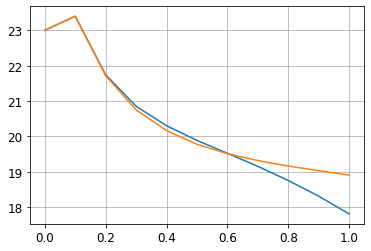

In [40]:
aln = b_Model()
setparams()
set_init(initvars)
aln.params['duration'] = 1.

control0 = aln.getZeroControl()
#control0 = step_control(maxI_ = 1.)

maxDelay = aln.getMaxDelay()
print("max delay = ", maxDelay)

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars
    
state_vars = aln.state_vars
init_vars = aln.init_vars

In [9]:
dur_pre = 0.
dur_post = 0.

max_it = 1
tol = 1e-16

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])


In [10]:
def plot_fig(i):
    lines = 8
    fig, axes = plt.subplots(lines,2, figsize=(18, 12))
    axes[0,i].plot(aln.t, control1[0,0,:], label="control exc")
    axes[0,i+1].plot(aln.t, control1[0,1,:], label="control inh")
    axes[1,i].plot(aln.t, aln.state["rates_exc"][0,:], label="rates exc")
    axes[1,i+1].plot(aln.t, aln.state["rates_inh"][0,:], label="rates inh")
    axes[2,i].plot(aln.t, aln.state["mufe"][0,:], label="mufe")
    axes[2,i+1].plot(aln.t, aln.state["mufi"][0,:], label="mufi")
    #axes[3,i].plot(aln.t, aln.state["IA"][0,:], label="IA")

    axes[4,i].plot(aln.t, aln.state["seem"][0,:], label="seem")
    axes[3,i].plot(aln.t, aln.state["seim"][0,:], label="seim")
    axes[4,i+1].plot(aln.t, aln.state["siem"][0,:], label="siem")
    axes[3,i+1].plot(aln.t, aln.state["siim"][0,:], label="siim")

    axes[5,i].plot(aln.t, aln.state["seev"][0,:], label="seev")
    axes[5,i+1].plot(aln.t, aln.state["seiv"][0,:], label="seiv")
    axes[6,i].plot(aln.t, aln.state["siev"][0,:], label="siev")
    axes[6,i+1].plot(aln.t, aln.state["siiv"][0,:], label="siiv")

    #axes[6,i].plot(aln.t, aln.state["mue_ou"][0,:], label="mue_ou")
    #axes[6,i+1].plot(aln.t, aln.state["mui_ou"][0,:], label="mui_ou")

    axes[7,i].plot(aln.t, aln.state["sigmae_f"][0,:], label="sigma_e")
    axes[7,i+1].plot(aln.t, aln.state["sigmai_f"][0,:], label="sigma_i")
    #axes[8,i].plot(aln.t, aln.state["Vmean_exc"][0,:], label="V_mean")
    #axes[9,i].plot(aln.t, aln.state["tau_exc"][0,:], label="tau_exc")
    #axes[9,i+1].plot(aln.t, aln.state["tau_inh"][0,:], label="tau_inh")

    for k in range(lines):
        for j in range(2):
            #if ((k,j) != (3,1) and (k,j) != (8,1)):
            axes[k,j].legend()

    plt.tight_layout()
    
def plot_phi(phi):
    lines = 9
    time = np.arange(0, dur+aln.params.dt, aln.params.dt)
    
    fig, axes = plt.subplots(lines,2, figsize=(18, 26))
    
    axes[0,0].plot(time, phi[0,0,:], label="phi0 - adjoint exc rate")
    axes[0,1].plot(time, phi[0,1,:], label="phi1 - adjoint inh rate")
    
    axes[1,0].plot(time, phi[0,2,:], label="phi2 - adjoint mufe")
    axes[1,1].plot(time, phi[0,3,:], label="phi3 - adjoint mufi")
    
    axes[2,0].plot(time, phi[0,6,:], label="phi6 - adjoint seim")
    axes[2,1].plot(time, phi[0,8,:], label="phi8 - adjoint siim")
    
    axes[3,0].plot(time, phi[0,4,:], label="phi4 - adjoint IA")
    axes[3,1].plot(time, phi[0,17,:], label="phi17 - adjoint V")
    
    axes[4,0].plot(time, phi[0,5,:], label="phi6 - adjoint seem")
    axes[4,1].plot(time, phi[0,7,:], label="phi8 - adjoint siem")
    
    axes[5,0].plot(time, phi[0,9,:], label="phi9 - adjoint seev")
    axes[5,0].plot(time, phi[0,10,:], label="phi10 - adjoint seiv")
    axes[5,1].plot(time, phi[0,11,:], label="phi11 - adjoint siev")
    axes[5,1].plot(time, phi[0,12,:], label="phi12 - adjoint siiv")
    
    axes[6,0].plot(time, phi[0,13,:], label="phi13 - adjoint mue ou")
    axes[6,1].plot(time, phi[0,14,:], label="phi14 - adjoint mui ou")
    
    axes[7,0].plot(time, phi[0,15,:], label="phi15 - adjoint sigma e")
    axes[7,1].plot(time, phi[0,16,:], label="phi16 - adjoint sigma i")
    
    axes[8,0].plot(time, phi[0,18,:], label="phi18 - adjoint tau e")
    axes[8,1].plot(time, phi[0,19,:], label="phi19 - adjoint tau i")

    for k in range(lines):
        for j in range(2):
            axes[k,j].legend()

    plt.tight_layout()

[15.         11.         15.84154908 16.07442292 16.89787185 17.19154398
 17.4608423  17.60517062 17.74977343 17.74922345 17.71651733]
[15.         11.         15.09964278 14.97681883 15.75714682 15.63944103
 15.48255457 14.84659904 14.63869806 14.37063054 14.11914171]


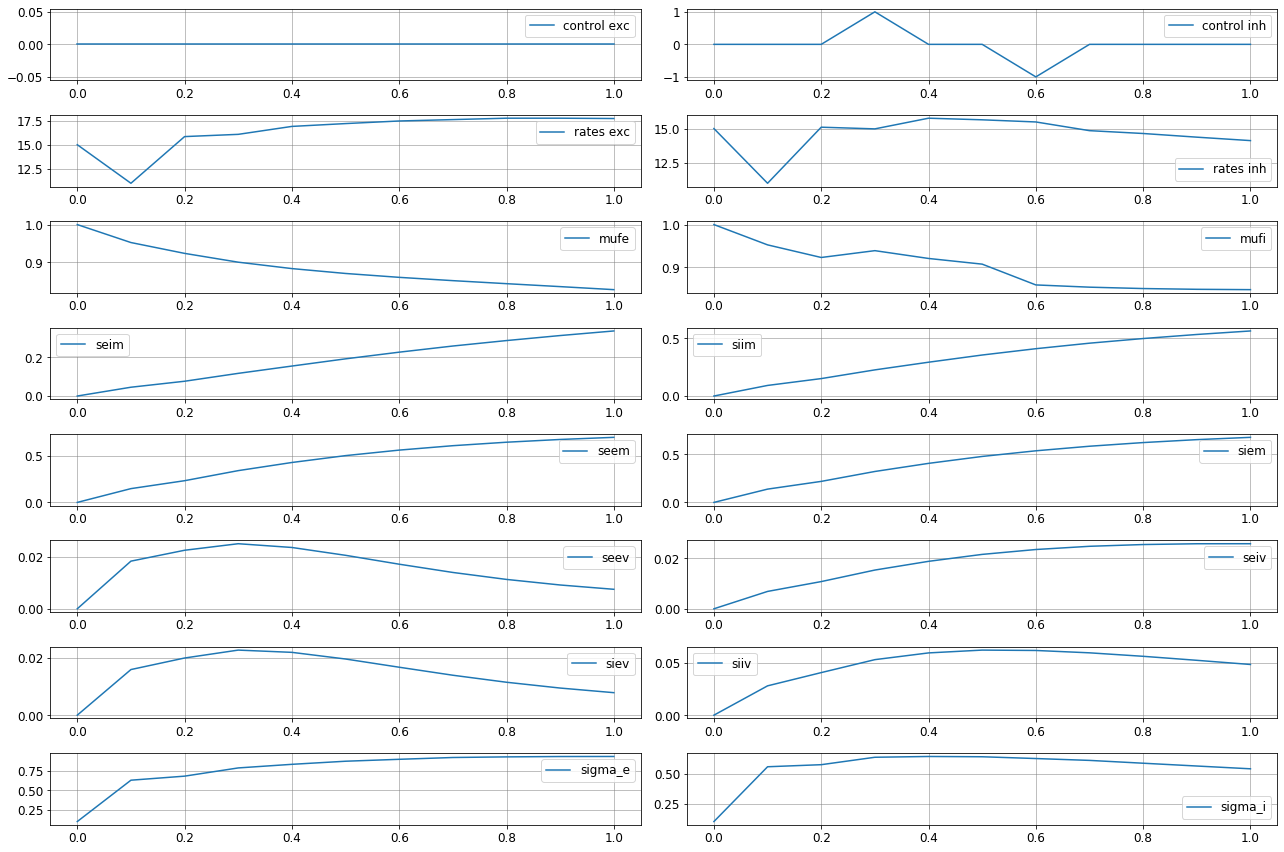

In [43]:
#setparams()

dur = 1.
aln.params.duration = dur
aln.params.di = 0.0

target = aln.getZeroTarget()
control1 = aln.getZeroControl()

set_init(initvars)

#control1[0,0,1] += 100.
#control1[0,0,:] += np.sin(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

control1 = aln.getZeroControl()
control1[0,1,6] -= 1.
control1[0,1,3] += 1.
#control1[0,1,:] += np.cos(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

aln.run(control=control1)

target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

plot_fig(0)
rates1 = aln.state["rates_exc"][0,:]
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])

[  0.          30.          29.75        29.50471698  29.26411997
 324.18920891 326.17477325 279.55271211 234.95173475 194.65484779
 167.72576433]
[ 0.         30.         29.75       29.50471698 31.79546325 31.5132445
 31.23590544 28.53835571 28.31680096 28.09974733 27.88715412]


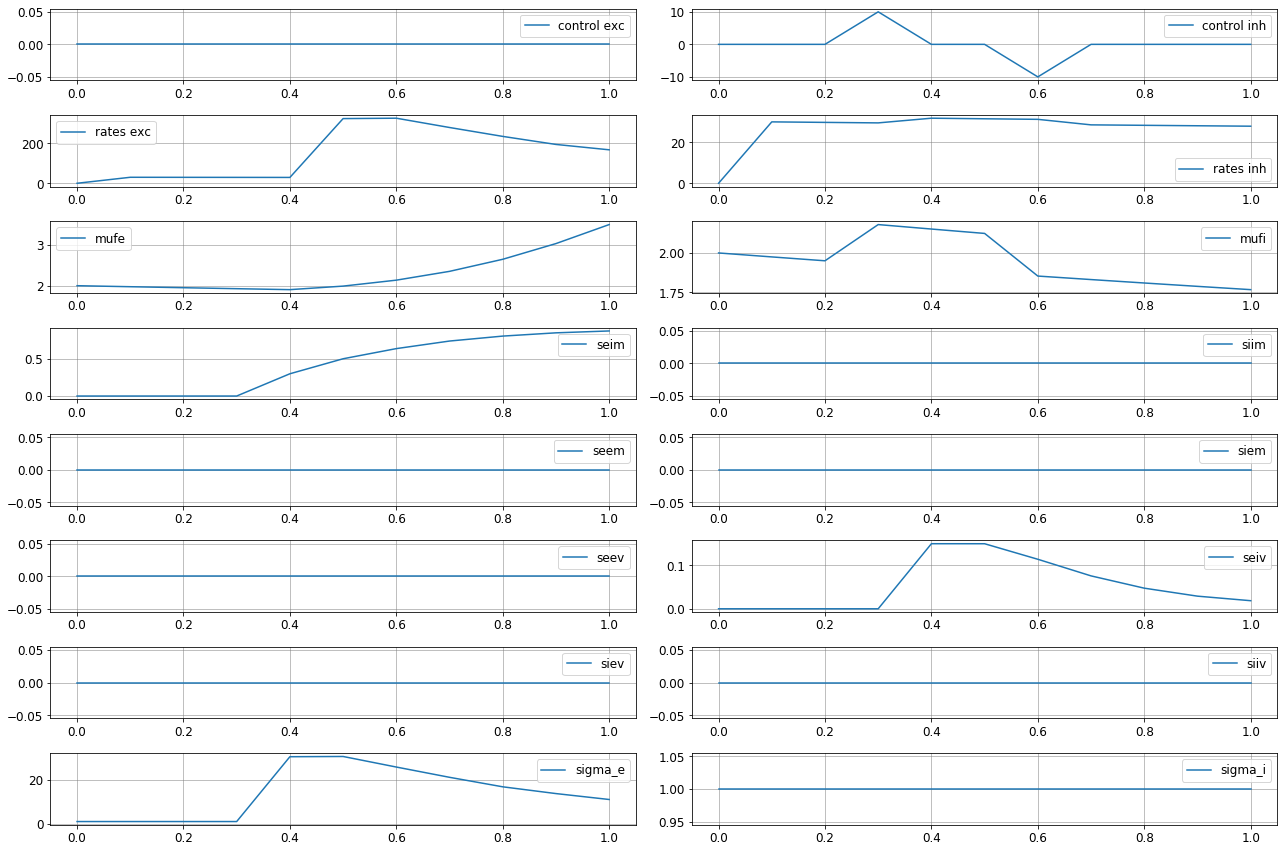

In [993]:
aln.params.di = 0.2
aln.run(control=control1)

rates2 = aln.state["rates_exc"][0,:]
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])
plot_fig(0)
target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

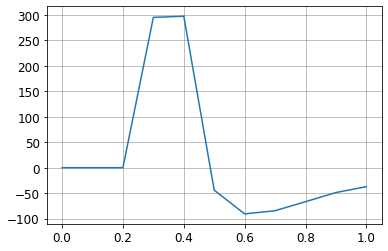

In [994]:
plt.plot(aln.t, rates1-rates2)

In [44]:
max_cntrl = 50. * 5.
start_step = 100.
cost_params = [1.0, 0.0, 0.0]

#aln.params.di = 0.0

cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = aln.getZeroControl()
#control2 = control1
#control2[0,1,:] += 0.1
#control2[0,1,7] += 0.1

max_it = 500
set_init(initvars)

A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(control2, target, c_scheme, u_mat,
        u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        variables_ = [0])

err = False
for c in range(len(A1_cost)-1):
    if A1_cost[c] < A1_cost[c+1]:
        print("ERROR in index ", c)
        err = True
        break
if not err:
    print("cost decreases throughout computation")
    
#print(grad)

set cost params
True 0
RUN  0 , total integrated cost =  0.00036514182955699496
test control change smaller than tolerance, return zero step
RUN  1 , total integrated cost =  0.00036514182955699496
Control only changes marginally.
Improved over  1  iterations by  0.0  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) 0.004139464113296553
min value of final gradient at index =  (array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1], dtype=int64), array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  9, 10],
      dtype=int64)) 0.0
cost decreases throughout computation


[23.         24.46345851 23.19012633 22.45907008 22.00798099 21.65952065
 21.37897715 21.07955373 20.76590307 20.36935201 19.92795471]
[ 0.          0.07246618 -0.0355178   0.91280136 -0.06826423 -0.03871874
 -0.96974024  0.09484848  0.13285423  0.          0.        ]
[23.         24.46345851 23.19012633 22.46023168 22.00816449 21.65918864
 21.37878219 21.0793311  20.76581606 20.36935929 19.928077  ]


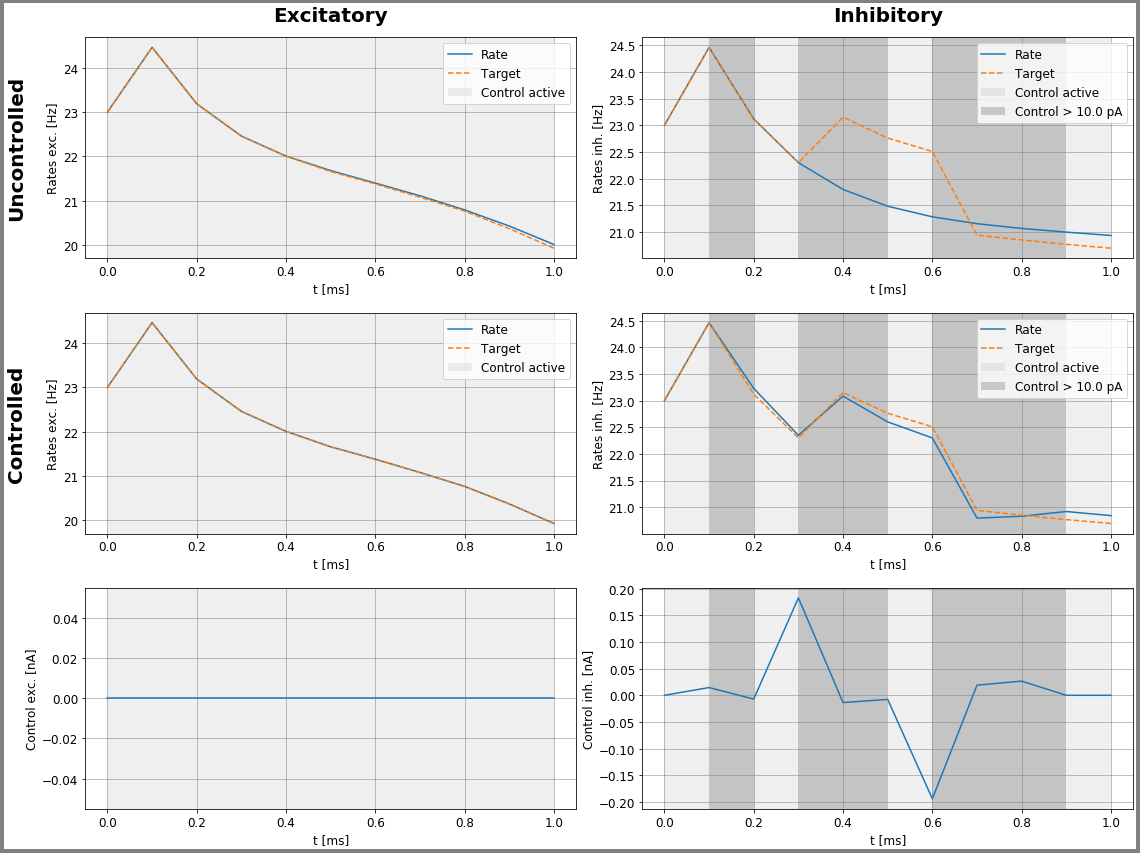

In [38]:
print(A1_bestState[0,0,:])
print(A1_bestControl[0,1,:])
print(target[0,0,:])
plotFunc.plot_control(aln, A1_bestControl, dur, dur_pre, dur_post, initvars, target,
                      path, filename_ = 'a1')

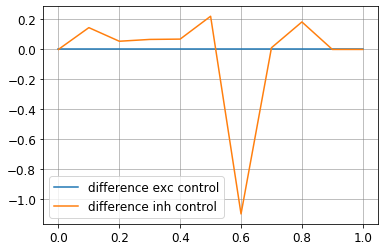

In [1085]:
cDiff = control1 - A1_bestControl
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

#plt.plot(aln.t, grad[0,1,:])
#plt.show()

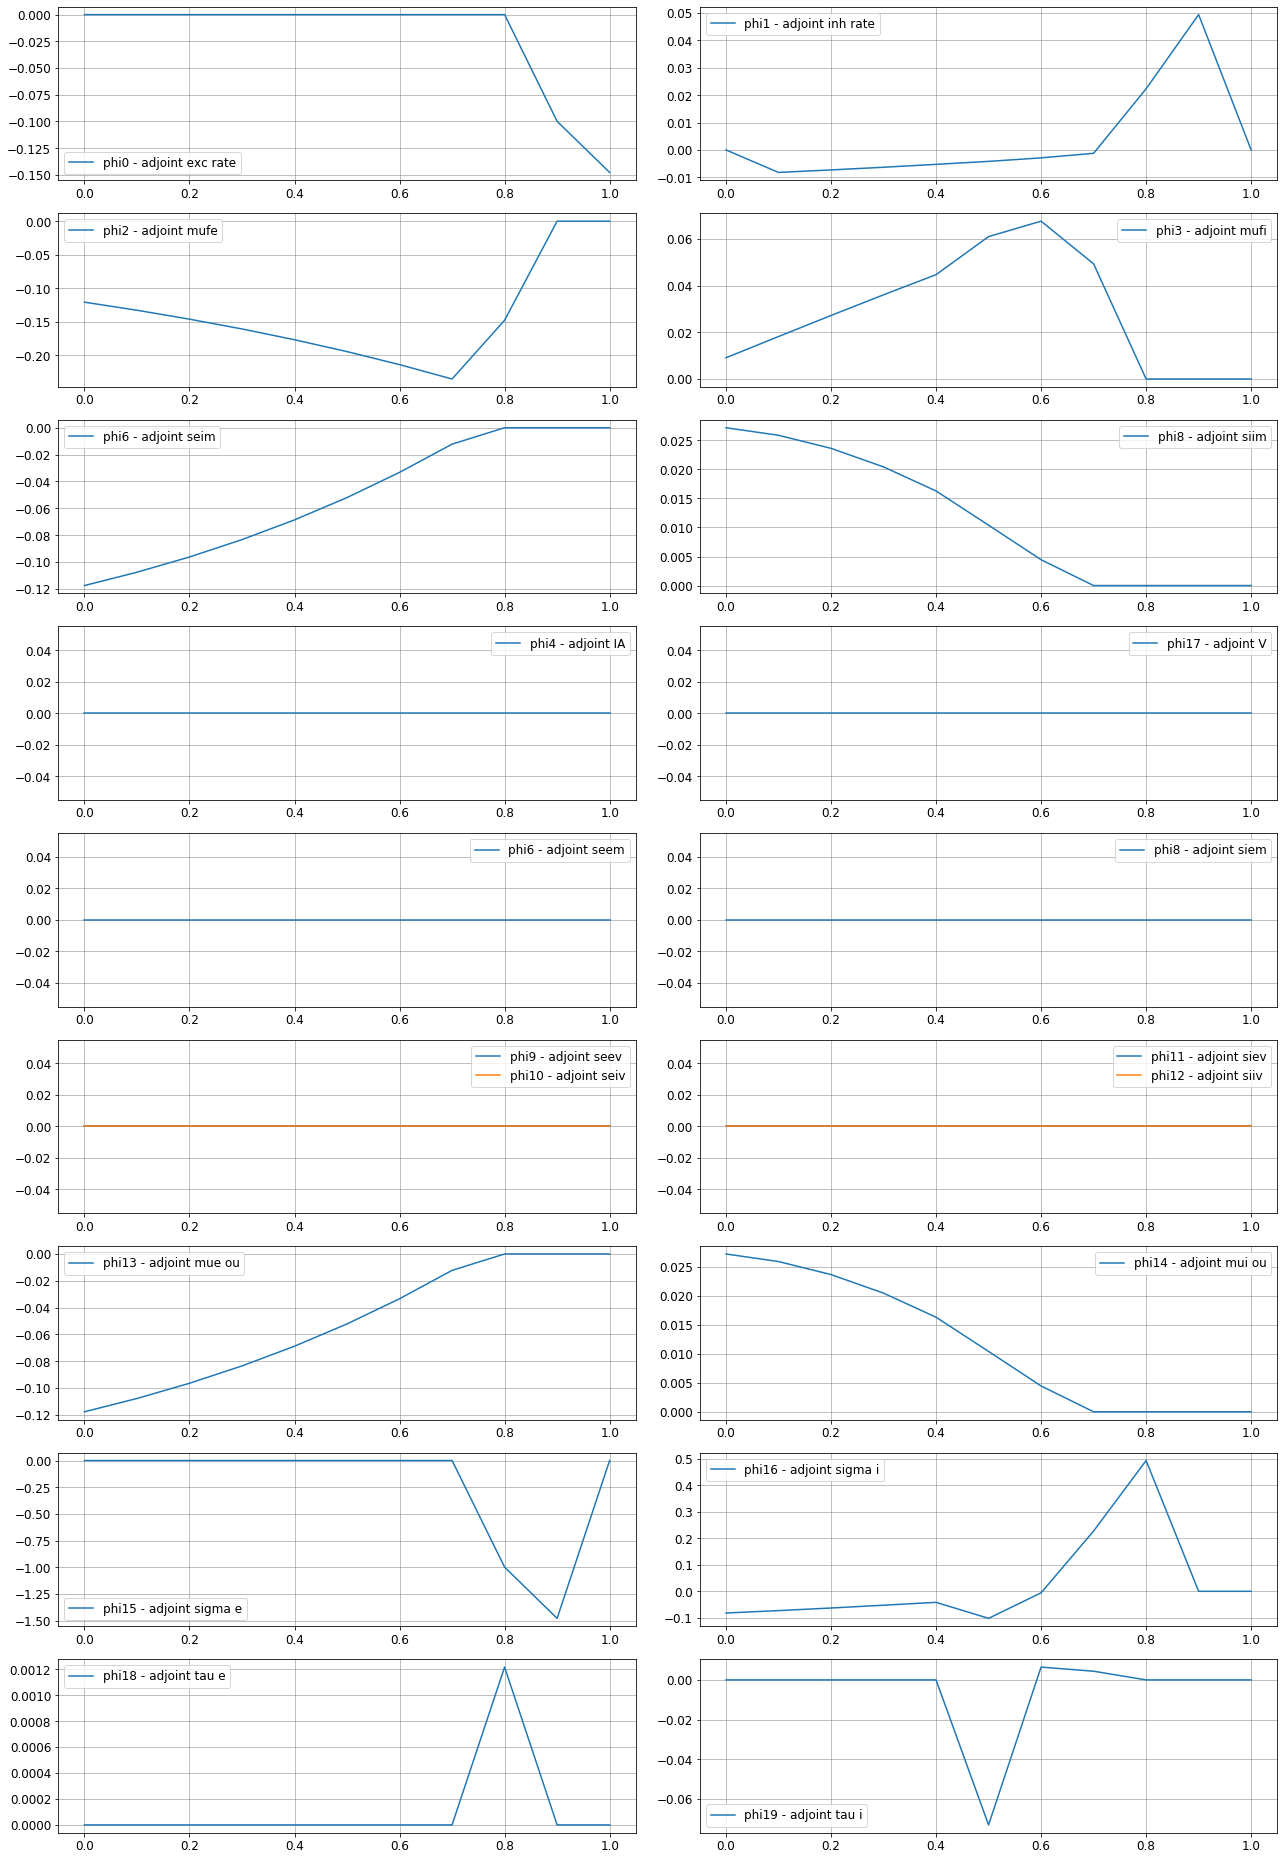

In [111]:
plot_phi(phi)

In [788]:
diff = np.zeros((phi.shape))
for ex in range(phi.shape[1]):
    if ex in [0,2,4,5,6,9,10,13,15,17,18]:
        diff[:,ex,:-1] = phi[:,ex,:-1]-phi_5e[:,ex,:1]
        diff[:,ex,0] = 0.
    else:
        diff[:,ex,:-1] = phi[:,ex,:-1]-phi_5e[:,ex,1:]
        diff[:,ex,0] = 0.

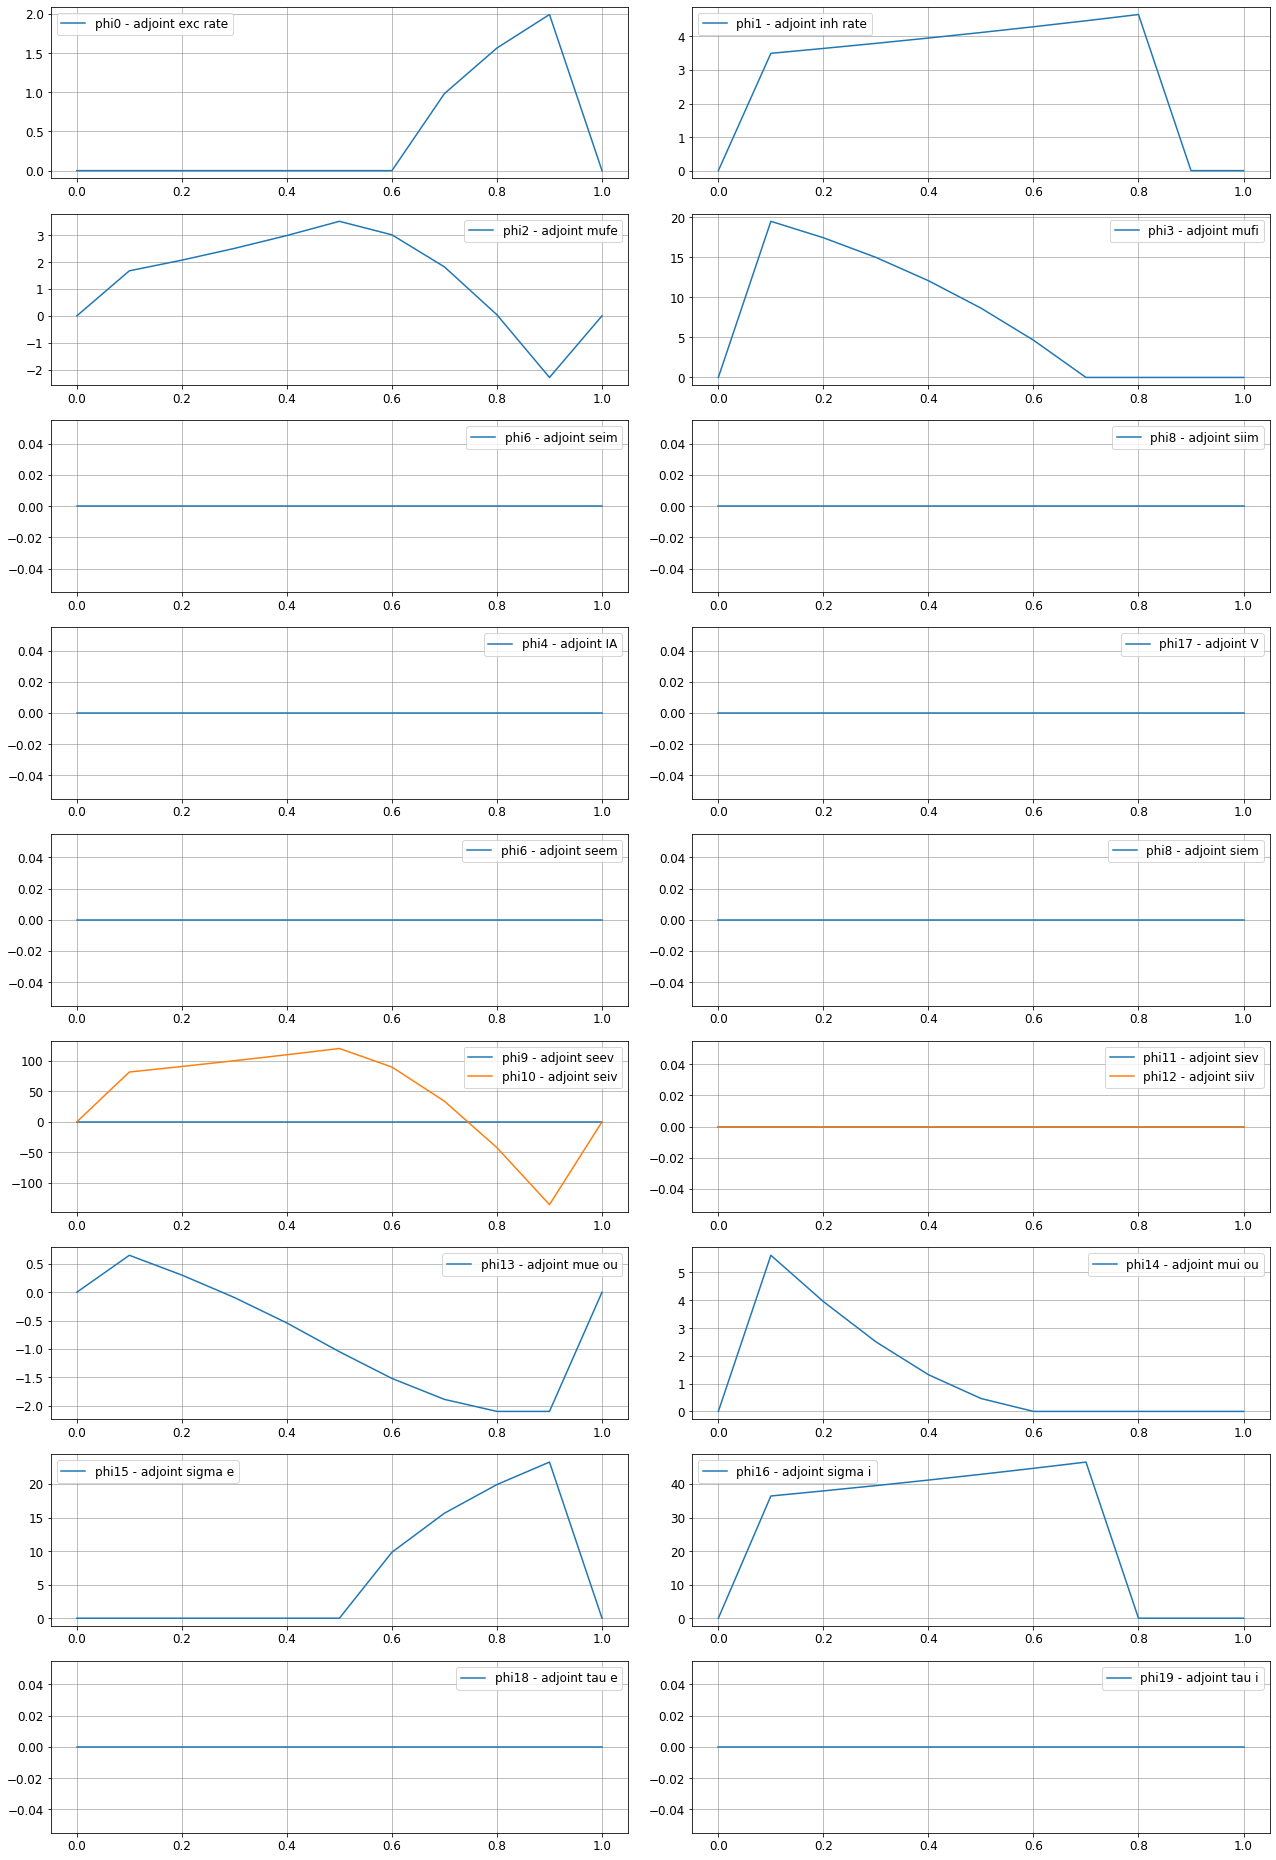

In [789]:
plot_phi(diff)

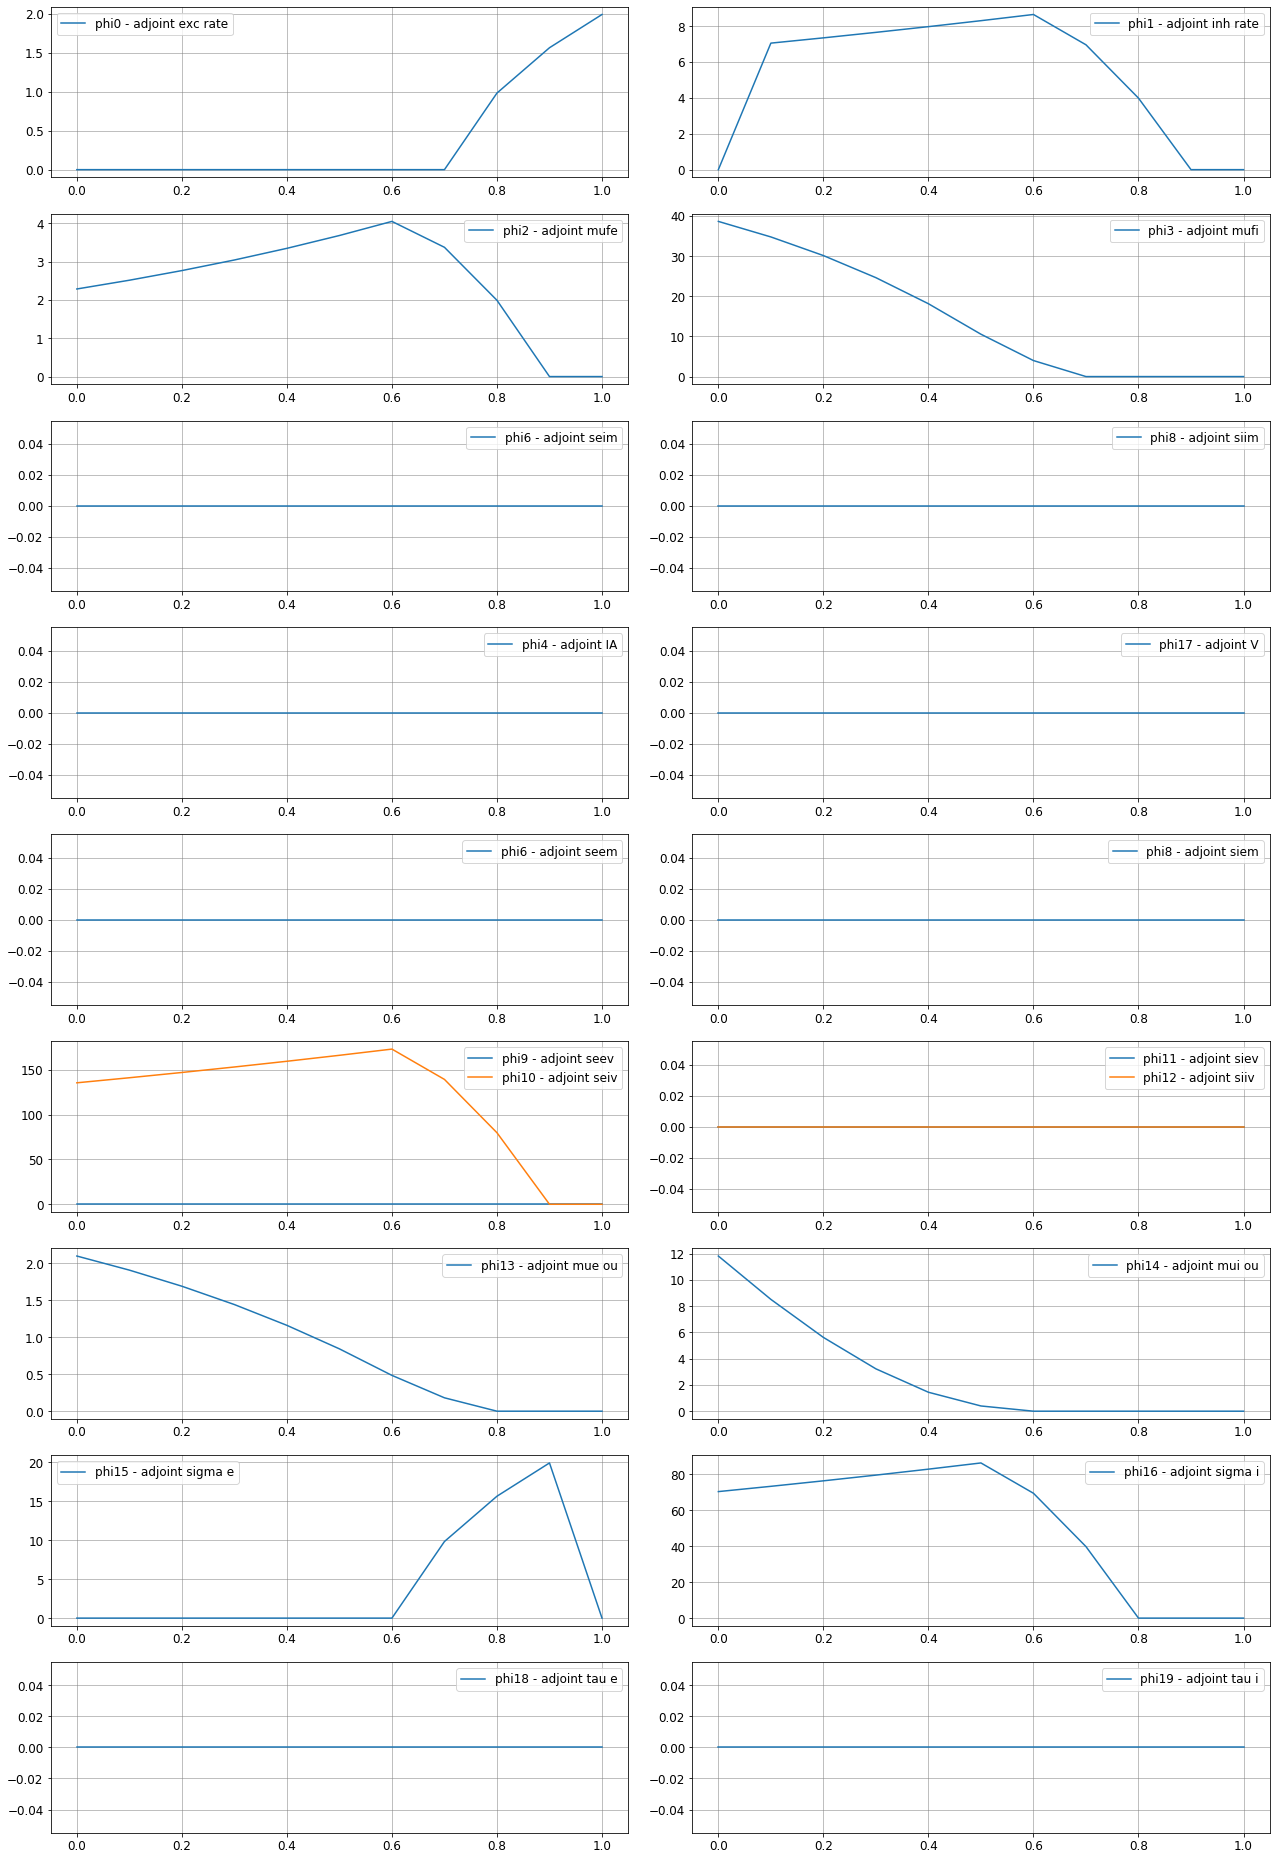

In [776]:
phi_5e = phi
plot_phi(phi_5e)

In [879]:
print(aln.params.di)

0.1
